## Diákok klaszterezése

### Történet
Egy középiskolában a tanárok szeretnék jobban megérteni a diákok teljesítményét és fizikai jellemzőit.  
Minden sor az **egyik diákot** jelenti, és négy tulajdonságot tartalmaz:

- **math_score**: a diák matematika pontszáma (0–100)  
- **english_score**: a diák angol pontszáma (0–100)  
- **height_cm**: a diák testmagassága centiméterben  
- **weight_kg**: a diák testtömege kilogrammban  

## Feladat 1 – Adatok beolvasása

Olvasd be a `students_clustering_data.csv` fájlt pandas-szal, és nézd meg az első néhány sort.  

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

df = pd.read_csv('students_clustering_data.csv')
df.head(5)

,math_score,english_score,height_cm,weight_kg
0,54.043483,68.282768,174.564326,71.179139
1,57.278086,65.554613,173.589186,62.956747
2,50.601478,87.572194,162.671474,61.457790
3,75.092457,77.310517,148.071582,47.599090
4,60.291044,59.285149,159.488007,59.743068


## Feladat 2 – Adatok vizualizálása

Vizualizáld a diákokat scatter ploton (`math_score` vs `english_score`).  

**Tippek:**  
- Használhatod a `matplotlib.pyplot.scatter()` függvényt.  
- Érdemes beállítani a **méretet (`s`)** és az **átlátszóságot (`alpha`)**, hogy a sűrűbb területek jól látszódjanak.  
- Mindig érdemes a tengelyeket feliratozni (`xlabel`, `ylabel`) és címet adni a diagramnak (`title`).

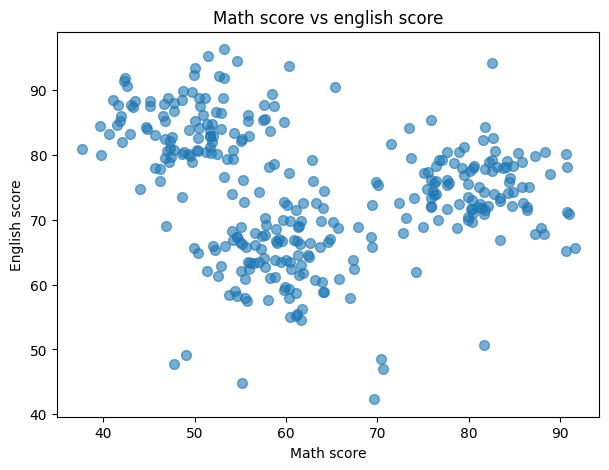

In [3]:
new_db = df[['math_score','english_score']]



plt.figure(figsize=(7,5))
plt.scatter(new_db['math_score'], new_db['english_score'], s=50, alpha=0.6)
plt.title('Math score vs english score')
plt.xlabel("Math score")
plt.ylabel("English score")
plt.show()

## Feladat 3 – DBSCAN futtatása

Tanítsd be a DBSCAN algoritmust a diákok jegyein (`math_score` és `english_score`).  

- Kísérletezz a paraméterekkel: `eps` és `min_samples`.  
- Tipp: Az optimális értékek **3 és 7 között** lehetnek.  
- Figyeld meg, hogyan változik a klaszterek száma és a zajpontok aránya a különböző beállításoknál.  

**Megjegyzés:**  
- Ne adj meg fix értékeket, próbálj ki több kombinációt a fenti tartományban.  
- Jegyezd fel, mely paraméterek mellett kapod a legértelmesebb klaszterezést.

<Axes: xlabel='math_score', ylabel='english_score'>

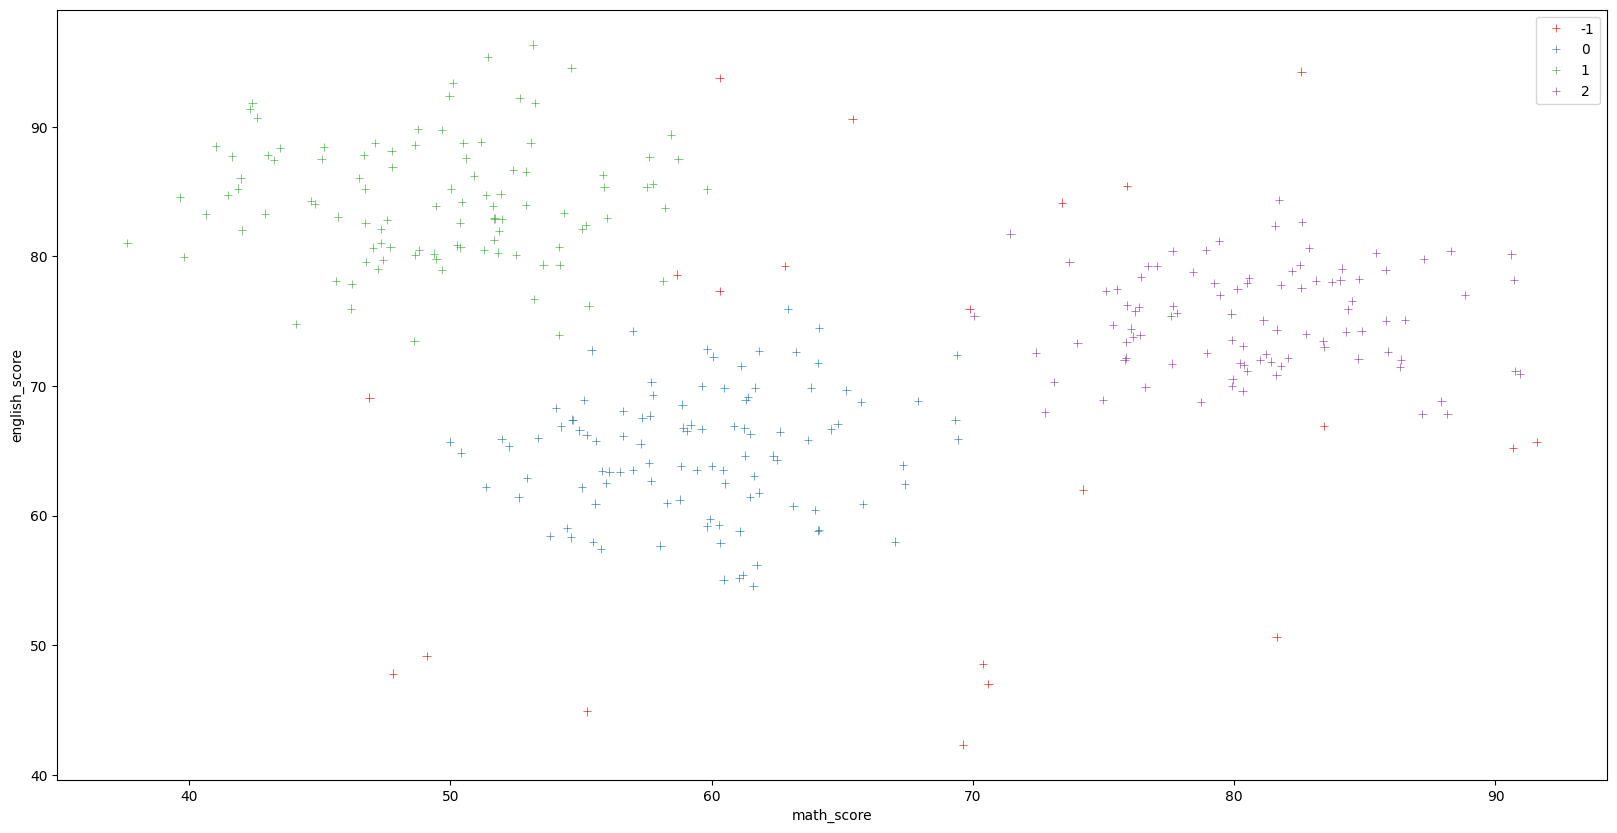

In [14]:
from sklearn.cluster import DBSCAN
import seaborn as sns

db = DBSCAN(eps=4,min_samples=7)
db.fit(new_db)
plt.figure(figsize=(20,10))
sns.scatterplot(x=new_db['math_score'], y=new_db['english_score'], marker='+', hue=db.labels_, palette="Set1")

## Feladat 4 – Hierarchikus klaszterezés a fizikai jellemzők alapján

### Feladat lépések

**1. lépés – Adatok kiválasztása**  
Válaszd ki a `height_cm` és `weight_kg` oszlopokat, és tárold egy új változóban, például `X_hw`.

*Megjegyzés:* Így könnyen kezelhető lesz az adathalmaz a klaszterezéshez.

**2. lépés – Linkage mátrix készítése**  
Hozd létre a linkage mátrixot a `linkage()` függvénnyel, `method='ward'` használatával.

*Megjegyzés:* A linkage mátrix tartalmazza, hogyan egyesülnek a pontok klaszterekké, és mennyi a közöttük lévő távolság.

**3. lépés – Dendrogram rajzolása**  
Készíts dendrogramot (`scipy.cluster.hierarchy.dendrogram()`) a linkage mátrixból, hogy vizuálisan is lásd a klaszterezés szerkezetét.

*Megjegyzés:* A dendrogram segít kiválasztani a klaszterek számát, és jól látható a klaszterek hierarchiája.

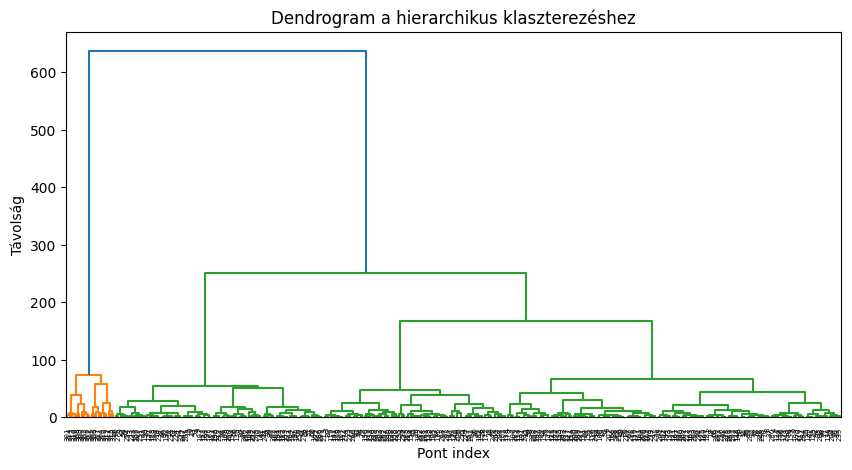

In [17]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

X_hw = df[['height_cm', 'weight_kg']]
Z = linkage(X_hw, method='ward')

plt.figure(figsize=(10,5))
dendrogram(Z, truncate_mode='level', p=20)  # csak a legfelső ágak (20 szintig)
plt.title("Dendrogram a hierarchikus klaszterezéshez")
plt.xlabel("Pont index")
plt.ylabel("Távolság")
plt.show()

## Feladat 5 – Klaszterek létrehozása és vizualizálása

Most hozzuk létre a tényleges klasztereket, és szemléltessük a fizikai jellemzők szerint.

### Feladat lépések

**1. lépés – Klaszterek létrehozása**  
Válaszd ki a klaszterek számát (például 4), és hozd létre a klasztercímkéket az `fcluster()` segítségével.

**2. lépés – Vizualizáció**  
Rajzold ki a klasztereket scatter ploton (`height_cm` vs `weight_kg`), minden klaszterhez külön színt használva.

*Megjegyzés:*  
- A scatter plot segítségével könnyen látható, hogy a diákok hogyan csoportosulnak fizikai jellemzőik alapján.  
- A klaszterek száma és elhelyezkedése a dendrogram alapján logikusan választható.

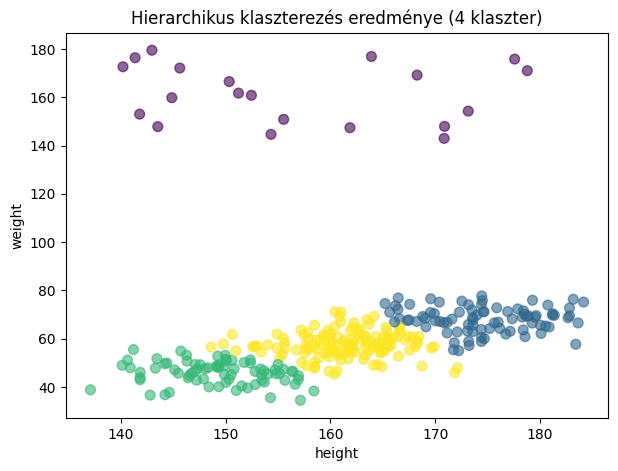

In [20]:
max_clusters = 4
labels = fcluster(Z, max_clusters, criterion='maxclust')

plt.figure(figsize=(7,5))
plt.scatter(df['height_cm'], df['weight_kg'], c=labels, s=50, alpha=0.6)
plt.title(f"Hierarchikus klaszterezés eredménye ({max_clusters} klaszter)")
plt.xlabel("height")
plt.ylabel("weight")
plt.show()